# Calculate d31 from power measurement

Bechthold1977 の簡略実装で省いている係数を戻して、位相整合点で測定した基本波パワーと SHG パワーから d を直接計算する。

$$P_{2\omega}=F_{\mathrm{Bechthold}}\frac{1024\pi^3 P_\omega^2 d^2}{cA}$$

$$d=\sqrt{\frac{P_{2\omega}cA}{1024\pi^3P_\omega^2F_{\mathrm{Bechthold}}}}$$

ここでは CGS 単位で計算し、最後に `1 esu = 4.192e8 pm/V` として変換する。

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "test_codes":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:

from types import SimpleNamespace
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fitting_strategies.bechthold1977 import Bechthold1977Strategy

In [3]:
C_CGS_CM_PER_S = 2.99792458e10
ESU_TO_PM_PER_V = 4.192e8


def watt_to_erg_per_s(power_w):
    return float(power_w) * 1e7


def beam_area_cm2(beam_x_um, beam_y_um, values_are_diameters=True):
    factor = 0.5 if values_are_diameters else 1.0
    rx_cm = float(beam_x_um) * factor * 1e-4
    ry_cm = float(beam_y_um) * factor * 1e-4
    return np.pi * rx_cm * ry_cm


def load_power_measurement(base_dir):
    base_dir = Path(base_dir)
    with (base_dir / "power_measurement.json").open(encoding="utf-8") as f:
        meta = json.load(f)

    scan_tables = []
    peak_rows = []
    for csv_path in sorted(base_dir.glob("theta*.csv")):
        df = pd.read_csv(csv_path)
        df["scan"] = csv_path.stem
        scan_tables.append(df)
        peak_rows.append(df.loc[df["power_w"].idxmax()].copy())

    shg_data = pd.concat(scan_tables, ignore_index=True) if scan_tables else pd.DataFrame()
    peaks = pd.DataFrame(peak_rows).sort_values("power_w", ascending=False).reset_index(drop=True)
    return meta, shg_data, peaks


def bechthold_factor(meta, theta_deg, input_polarization_deg, detected_polarization_deg, d_component="d_31", dn_override=None):
    calc_meta = dict(meta)
    calc_meta["wavelength_nm"] = calc_meta.get("wavelength_nm", calc_meta["fundamental_wavelength_nm"])
    calc_meta["input_polarization"] = input_polarization_deg
    calc_meta["detected_polarization"] = detected_polarization_deg
    calc_meta["d_component"] = d_component

    data = pd.DataFrame({"position": [float(theta_deg)], "intensity_corrected": [1.0]})
    strategy = Bechthold1977Strategy(SimpleNamespace(meta=calc_meta, data=data))
    model, aux = strategy._maker_fringes(
        override={"theta_deg": np.array([float(theta_deg)]), "dn_override": dn_override},
        return_aux=True,
    )

    normalized_factor = float(np.asarray(model).reshape(-1)[0])
    d_factor = float(np.asarray(aux["d_factor"]).reshape(-1)[0])
    unnormalized_factor = normalized_factor * d_factor
    return normalized_factor, unnormalized_factor, aux


def calc_d_from_power(fundamental_power_w, shg_power_w, bechthold_factor_value, area_cm2):
    p_w_cgs = watt_to_erg_per_s(fundamental_power_w)
    p_2w_cgs = watt_to_erg_per_s(shg_power_w)
    d_esu = np.sqrt(
        p_2w_cgs * C_CGS_CM_PER_S * area_cm2
        / (1024.0 * np.pi**3 * p_w_cgs**2 * float(bechthold_factor_value))
    )
    return d_esu, d_esu * ESU_TO_PM_PER_V

In [4]:
BASE_DIR = Path(r"X:\Anlagen\_lab31316-nlo\Inbox\experiment\202605_PM_power_measurement_results\20260522_172847_BMF12-C-1_power_d31")

meta, shg_data, shg_peaks = load_power_measurement(BASE_DIR)

fundamental_power_w = meta["fundamental_power"]["mean_w"]
best_peak = shg_peaks.iloc[0]
theta_pm_deg = float(best_peak["angle_deg"])
shg_power_w = float(best_peak["power_w"])

print(f"fundamental: {fundamental_power_w * 1e3:.6g} mW")
print(f"SHG peak:    {shg_power_w * 1e6:.6g} uW at {theta_pm_deg:.6g} deg")
display(shg_peaks[["scan", "angle_deg", "power_w", "std_w", "n"]])

fundamental: 59.6316 mW
SHG peak:    2.62258 uW at -13.65 deg


,scan,angle_deg,power_w,std_w,n
0,theta2,-13.65,0.000003,6.069319e-08,31
1,theta1,13.75,0.000003,1.573718e-07,31


In [5]:
# d31: BaMgF4, (010) cut, rotation axis 100, input 0 deg, detected 90 deg
input_polarization_deg = 0
detected_polarization_deg = 90
d_component = "d_31"

# Existing Bechthold fitting code divides beam_r_x/y by 2 internally, so these metadata values are treated as diameters.
beam_values_are_diameters = True

# The strategy returns a normalized curve. For absolute power, use the unnormalized Bechthold factor.
use_unnormalized_bechthold_factor = True

# Refractive-index offsets from fitting. Missing keys are treated as zero.
# Supported key styles: dn_w_a / dn_2w_c, or w_a / 2w_c.
# dn_override = {
#     "dn_w_a": 0.00009,
#     "dn_2w_b": -0.00055,
#     "dn_2w_c": -0.00005
# }
dn_override = {
    "dn_w_a": -0.00015,
    "dn_2w_b": -0.00027,
    "dn_2w_c": -0.00015
}

In [6]:
normalized_F, unnormalized_F, aux = bechthold_factor(
    meta,
    theta_pm_deg,
    input_polarization_deg=input_polarization_deg,
    detected_polarization_deg=detected_polarization_deg,
    d_component=d_component,
    dn_override=dn_override,
)
F = unnormalized_F if use_unnormalized_bechthold_factor else normalized_F

area_cm2 = beam_area_cm2(
    meta["beam_r_x"],
    meta["beam_r_y"],
    values_are_diameters=beam_values_are_diameters,
)
d_esu, d_pm_per_v = calc_d_from_power(fundamental_power_w, shg_power_w, F, area_cm2)

result = pd.Series(
    {
        "theta_pm_deg": theta_pm_deg,
        "fundamental_power_mW": fundamental_power_w * 1e3,
        "shg_power_uW": shg_power_w * 1e6,
        "beam_area_cm2": area_cm2,
        "bechthold_F_normalized": normalized_F,
        "bechthold_d_factor": float(np.asarray(aux["d_factor"]).reshape(-1)[0]),
        "bechthold_F_used": F,
        "d_esu": d_esu,
        "d_pm_per_V": d_pm_per_v,
    }
)
display(result.to_frame("value"))

,value
theta_pm_deg,-1.365000e+01
fundamental_power_mW,5.963158e+01
shg_power_uW,2.622581e+00
beam_area_cm2,1.196004e-03
bechthold_F_normalized,3.080736e+00
bechthold_d_factor,6.360942e+04
bechthold_F_used,1.959638e+05
d_esu,6.519317e-07
d_pm_per_V,2.732898e+02


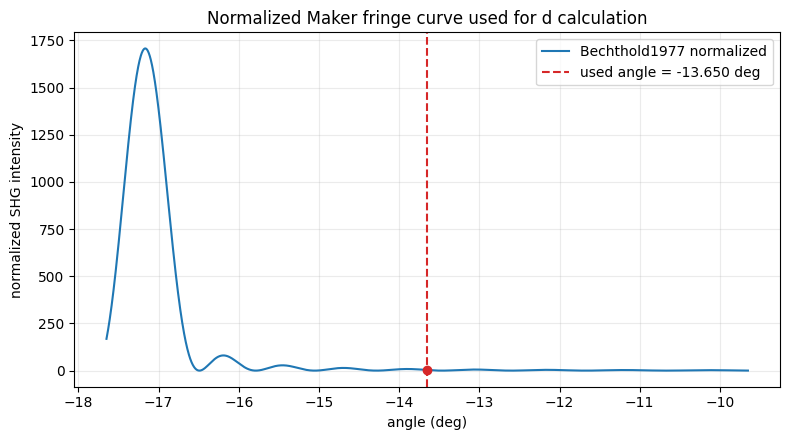

In [7]:
theta_plot = np.linspace(theta_pm_deg - 4.0, theta_pm_deg + 4.0, 2000)

plot_meta = dict(meta)
plot_meta["wavelength_nm"] = plot_meta.get("wavelength_nm", plot_meta["fundamental_wavelength_nm"])
plot_meta["input_polarization"] = input_polarization_deg
plot_meta["detected_polarization"] = detected_polarization_deg
plot_meta["d_component"] = d_component

plot_data = pd.DataFrame({"position": theta_plot, "intensity_corrected": np.ones_like(theta_plot)})
strategy = Bechthold1977Strategy(SimpleNamespace(meta=plot_meta, data=plot_data))
maker_norm = strategy._maker_fringes(override={"theta_deg": theta_plot, "dn_override": dn_override})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_plot, maker_norm, label="Bechthold1977 normalized")
ax.axvline(theta_pm_deg, color="C3", linestyle="--", linewidth=1.5, label=f"used angle = {theta_pm_deg:.3f} deg")
ax.scatter([theta_pm_deg], [normalized_F], color="C3", zorder=3)
ax.set_xlabel("angle (deg)")
ax.set_ylabel("normalized SHG intensity")
ax.set_title("Normalized Maker fringe curve used for d calculation")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

## Manual input

CSV を使わずに値を直接入れたい場合は、下のセルだけ編集する。

In [8]:
manual_fundamental_mw = 59.631578947368424
manual_shg_uw = 2.6225806451612904
manual_theta_pm_deg = -13.65
manual_beam_x_um = 360.0
manual_beam_y_um = 423.0

manual_normalized_F, manual_unnormalized_F, manual_aux = bechthold_factor(
    meta,
    manual_theta_pm_deg,
    input_polarization_deg=input_polarization_deg,
    detected_polarization_deg=detected_polarization_deg,
    d_component=d_component,
    dn_override=dn_override,
)
manual_normalized_F = manual_normalized_F*1700
manual_unnormalized_F = manual_unnormalized_F*1700

manual_F = manual_unnormalized_F if use_unnormalized_bechthold_factor else manual_normalized_F
manual_area_cm2 = beam_area_cm2(manual_beam_x_um, manual_beam_y_um, values_are_diameters=beam_values_are_diameters)
manual_d_esu, manual_d_pm_per_v = calc_d_from_power(
    manual_fundamental_mw * 1e-3,
    manual_shg_uw * 1e-6,
    manual_F,
    manual_area_cm2,
)

pd.Series(
    {
        "manual_bechthold_F_used": manual_F,
        "manual_d_esu": manual_d_esu,
        "manual_d_pm_per_V": manual_d_pm_per_v,
    }
).to_frame("value")

,value
manual_bechthold_F_used,3.331385e+08
manual_d_esu,1.581167e-08
manual_d_pm_per_V,6.628250e+00
